# Phần 3: Phân Tích Benchmark và So Sánh Hiệu Năng

**Người làm:** Thoại

**Mục tiêu:**
- Đọc và chuẩn hóa dữ liệu benchmark đã xuất ra từ `benchmark_results.json`.
- Trình bày bảng số liệu tổng hợp theo phương pháp và loại ma trận.
- Vẽ biểu đồ log-log cho thời gian và sai số để quan sát xu hướng tăng theo kích thước $n$.
- So sánh trực quan giữa các phương pháp trên từng loại ma trận.
- Rút ra nhận xét về tốc độ và độ ổn định số.

**Nguồn dữ liệu:**
- `benchmark_results.json`: dữ liệu có cấu trúc, dùng làm đầu vào chính cho notebook.
- `benchmark.txt`: log terminal giúp đối chiếu kết quả chạy và kiểm tra nhanh quá trình benchmark.


## Môi Trường Chạy Benchmark

| Thành phần | Thông tin |
|:-----------|:----------|
| **Phần cứng — CPU** | Intel Core i7-14700 |
| **Phần cứng — RAM** | 8 GB |
| **Phần mềm — IDE** | VS Code |
| **Phần mềm — Python** | 3.13.9 |
| **Phần mềm — Hệ điều hành** | Windows |

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# Thiết lập phong cách hiển thị để notebook dễ đọc và đồng nhất
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "font.family": "DejaVu Sans",
    }
)

# Đường dẫn tới file dữ liệu benchmark xuất từ phần 3
BENCHMARK_PATH = Path("benchmark_results.json")

# Thứ tự cố định để trình bày bảng và biểu đồ nhất quán
MATRIX_ORDER = ["random", "spd", "hilbert"]
METHOD_ORDER = [
    "Gauss-Jordan (Part 1)",
    "SVD Decomposition (Part 2)",
    "Gauss-Seidel",
]

# Màu cố định cho từng phương pháp để dễ đối chiếu trên nhiều đồ thị
METHOD_COLORS = {
    "Gauss-Jordan (Part 1)": "#1f77b4",
    "SVD Decomposition (Part 2)": "#d62728",
    "Gauss-Seidel": "#2ca02c",
}

# Nhãn hiển thị đẹp hơn cho từng loại ma trận
MATRIX_LABELS = {
    "random": "Random matrix",
    "spd": "SPD matrix",
    "hilbert": "Hilbert matrix",
}

# Ngưỡng cắt hiển thị cho sai số (chỉ dùng khi vẽ) để tránh outlier làm bẹp đồ thị.
# Bảng số liệu vẫn luôn hiển thị giá trị thật, không cắt.
ERROR_PLOT_CAP = 1e6


def load_results(path: Path = BENCHMARK_PATH) -> pd.DataFrame:
    """Đọc file JSON benchmark, kiểm tra cột cần thiết và chuẩn hóa kiểu dữ liệu."""

    # Bước 1: đọc toàn bộ dữ liệu từ file JSON
    with path.open("r", encoding="utf-8") as f:
        raw_data = json.load(f)

    # Bước 2: chuyển sang DataFrame để xử lý bảng dễ hơn
    df = pd.DataFrame(raw_data)
    required_columns = {
        "method",
        "avg_time_sec",
        "avg_relative_error",
        "converged",
        "iterations",
        "success",
        "note",
        "n",
        "matrix_type",
    }

    # Bước 3: xác nhận dữ liệu đầu vào không thiếu cột
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Thiếu cột trong dữ liệu benchmark: {sorted(missing_columns)}")

    # Bước 4: ép kiểu để tránh lỗi khi nhóm, vẽ đồ thị và định dạng bảng
    df = df.copy()
    df["n"] = pd.to_numeric(df["n"], errors="raise").astype(int)
    df["avg_time_sec"] = pd.to_numeric(df["avg_time_sec"], errors="coerce")
    df["avg_relative_error"] = pd.to_numeric(df["avg_relative_error"], errors="coerce")
    df["note"] = df["note"].fillna("")
    df["matrix_type"] = pd.Categorical(df["matrix_type"], categories=MATRIX_ORDER, ordered=True)
    df["method"] = pd.Categorical(df["method"], categories=METHOD_ORDER, ordered=True)

    # Trả về dữ liệu đã sắp xếp theo loại ma trận, kích thước và phương pháp
    return df.sort_values(["matrix_type", "n", "method"]).reset_index(drop=True)


def format_scientific(value: float) -> str:
    """Định dạng số theo ký hiệu khoa học để bảng sai số gọn và rõ."""

    if pd.isna(value):
        return "-"
    return f"{value:.2e}"


def format_seconds(value: float) -> str:
    """Định dạng thời gian trung bình theo giây."""

    if pd.isna(value):
        return "-"
    return f"{value:.4f}"


# Nạp dữ liệu đã benchmark và lọc riêng các bản ghi thành công
# success_df là nguồn dữ liệu chính cho các bảng và biểu đồ bên dưới
df = load_results()
success_df = df[df["success"]].copy()

print(f"Tổng số bản ghi: {len(df)}")
print(f"Số bản ghi thành công: {len(success_df)}")
print(f"Các loại ma trận: {list(df['matrix_type'].cat.categories)}")
print(f"Các phương pháp: {list(df['method'].cat.categories)}")

display(df.head(9))


Tổng số bản ghi: 45
Số bản ghi thành công: 45
Các loại ma trận: ['random', 'spd', 'hilbert']
Các phương pháp: ['Gauss-Jordan (Part 1)', 'SVD Decomposition (Part 2)', 'Gauss-Seidel']


,method,avg_time_sec,avg_relative_error,converged,iterations,success,note,n,matrix_type
0,Gauss-Jordan (Part 1),0.006119,4.200174e-16,True,NaN,True,,50,random
1,SVD Decomposition (Part 2),0.107396,1.821364e-15,True,NaN,True,,50,random
2,Gauss-Seidel,0.001132,4.058049e-14,True,9.0,True,Hội tụ sau 9 vòng lặp (chéo trội),50,random
3,Gauss-Jordan (Part 1),0.045013,6.249794e-16,True,NaN,True,,100,random
4,SVD Decomposition (Part 2),0.852775,3.996644e-12,True,NaN,True,,100,random
5,Gauss-Seidel,0.003509,2.402194e-15,True,9.0,True,Hội tụ sau 9 vòng lặp (chéo trội),100,random
6,Gauss-Jordan (Part 1),0.339560,8.233254e-16,True,NaN,True,,200,random
7,SVD Decomposition (Part 2),7.373604,6.362979e-13,True,NaN,True,,200,random
8,Gauss-Seidel,0.012767,1.349195e-14,True,8.0,True,Hội tụ sau 8 vòng lặp (chéo trội),200,random


## 3.1 Bảng Số Liệu Tổng Hợp

Bảng dưới đây tóm tắt thời gian chạy trung bình và sai số tương đối trung bình theo từng loại ma trận và phương pháp. Dữ liệu đã được lọc từ `benchmark_results.json` và chỉ giữ các bản ghi thành công.


In [12]:
# Gom dữ liệu theo từng loại ma trận và từng phương pháp
# Ý tưởng: tính trung bình để có một bảng tóm tắt gọn cho báo cáo
summary_table = (
    success_df.groupby(["matrix_type", "method"], observed=True)[["avg_time_sec", "avg_relative_error"]]
    .mean()
    .reset_index()
    .sort_values(["matrix_type", "method"])
)

# Định dạng lại bảng cho dễ đọc trong notebook
summary_table_display = summary_table.copy()
summary_table_display["avg_time_sec"] = summary_table_display["avg_time_sec"].map(format_seconds)
summary_table_display["avg_relative_error"] = summary_table_display["avg_relative_error"].map(format_scientific)
summary_table_display = summary_table_display.rename(
    columns={
        "matrix_type": "Loại ma trận",
        "method": "Phương pháp",
        "avg_time_sec": "Thời gian TB (s)",
        "avg_relative_error": "Sai số TB",
    }
)

display(Markdown("### Bảng tổng hợp theo loại ma trận và phương pháp"))
display(summary_table_display)

# Tìm phương pháp nhanh nhất cho từng cặp (loại ma trận, kích thước n)
# Dùng idxmin để lấy hàng có thời gian nhỏ nhất trong mỗi nhóm
fastest_table = (
    success_df.loc[success_df.groupby(["matrix_type", "n"], observed=True)["avg_time_sec"].idxmin(),
                   ["matrix_type", "n", "method", "avg_time_sec", "avg_relative_error"]]
    .sort_values(["matrix_type", "n"])
    .reset_index(drop=True)
)

fastest_table_display = fastest_table.copy()
fastest_table_display["avg_time_sec"] = fastest_table_display["avg_time_sec"].map(format_seconds)
fastest_table_display["avg_relative_error"] = fastest_table_display["avg_relative_error"].map(format_scientific)
fastest_table_display = fastest_table_display.rename(
    columns={
        "matrix_type": "Loại ma trận",
        "n": "Kích thước n",
        "method": "Phương pháp nhanh nhất",
        "avg_time_sec": "Thời gian TB (s)",
        "avg_relative_error": "Sai số TB",
    }
)

display(Markdown("### Phương pháp nhanh nhất theo từng kích thước"))
display(fastest_table_display)

# Bảng checkpoint cho n lớn nhất để tránh nhận xét nhầm khi dữ liệu benchmark thay đổi
n_max = int(success_df["n"].max())
checkpoint = (
    success_df[success_df["n"] == n_max][["matrix_type", "method", "avg_time_sec", "avg_relative_error", "iterations", "converged"]]
    .sort_values(["matrix_type", "avg_time_sec"])
    .reset_index(drop=True)
)
checkpoint_display = checkpoint.copy()
checkpoint_display["avg_time_sec"] = checkpoint_display["avg_time_sec"].map(format_seconds)
checkpoint_display["avg_relative_error"] = checkpoint_display["avg_relative_error"].map(format_scientific)
checkpoint_display = checkpoint_display.rename(
    columns={
        "matrix_type": "Loại ma trận",
        "method": "Phương pháp",
        "avg_time_sec": "Thời gian TB (s)",
        "avg_relative_error": "Sai số",
        "iterations": "Số vòng lặp",
        "converged": "Hội tụ",
    }
)
display(Markdown(f"### Checkpoint số liệu tại n = {n_max}"))
display(checkpoint_display)


### Bảng tổng hợp theo loại ma trận và phương pháp

,Loại ma trận,Phương pháp,Thời gian TB (s),Sai số TB
0,random,Gauss-Jordan (Part 1),10.0184,1.00e-15
1,random,SVD Decomposition (Part 2),316.8660,9.32e-13
2,random,Gauss-Seidel,0.1134,1.20e-14
3,spd,Gauss-Jordan (Part 1),15.0220,1.12e-15
4,spd,SVD Decomposition (Part 2),331.3570,7.60e-11
5,spd,Gauss-Seidel,9.1844,9.75e-08
6,hilbert,Gauss-Jordan (Part 1),0.3606,1.19e+09
7,hilbert,SVD Decomposition (Part 2),39.5144,5.02e-05
8,hilbert,Gauss-Seidel,9.3767,8.33e-05


### Phương pháp nhanh nhất theo từng kích thước

,Loại ma trận,Kích thước n,Phương pháp nhanh nhất,Thời gian TB (s),Sai số TB
0,random,50,Gauss-Seidel,0.0011,4.06e-14
1,random,100,Gauss-Seidel,0.0035,2.40e-15
2,random,200,Gauss-Seidel,0.0128,1.35e-14
3,random,500,Gauss-Seidel,0.0813,4.74e-16
4,random,1000,Gauss-Seidel,0.4684,3.16e-15
5,spd,50,Gauss-Jordan (Part 1),0.0055,3.75e-16
6,spd,100,Gauss-Jordan (Part 1),0.0444,7.68e-16
7,spd,200,Gauss-Jordan (Part 1),0.3480,9.85e-16
8,spd,500,Gauss-Jordan (Part 1),5.3594,1.39e-15
9,spd,1000,Gauss-Seidel,36.0938,4.84e-07


### Checkpoint số liệu tại n = 1000

,Loại ma trận,Phương pháp,Thời gian TB (s),Sai số,Số vòng lặp,Hội tụ
0,random,Gauss-Seidel,0.4684,3.16e-15,7.0,True
1,random,Gauss-Jordan (Part 1),44.2364,1.83e-15,NaN,True
2,random,SVD Decomposition (Part 2),1441.2578,1.04e-14,NaN,True
3,spd,Gauss-Seidel,36.0938,4.84e-07,1000.0,False
4,spd,Gauss-Jordan (Part 1),69.3527,2.11e-15,NaN,True
5,spd,SVD Decomposition (Part 2),1482.2361,4.44e-12,NaN,True
6,hilbert,Gauss-Jordan (Part 1),1.4179,5.93e+09,NaN,True
7,hilbert,Gauss-Seidel,36.2495,2.60e-04,1000.0,False
8,hilbert,SVD Decomposition (Part 2),175.5360,1.16e-04,NaN,True


### Biểu đồ thời gian chạy


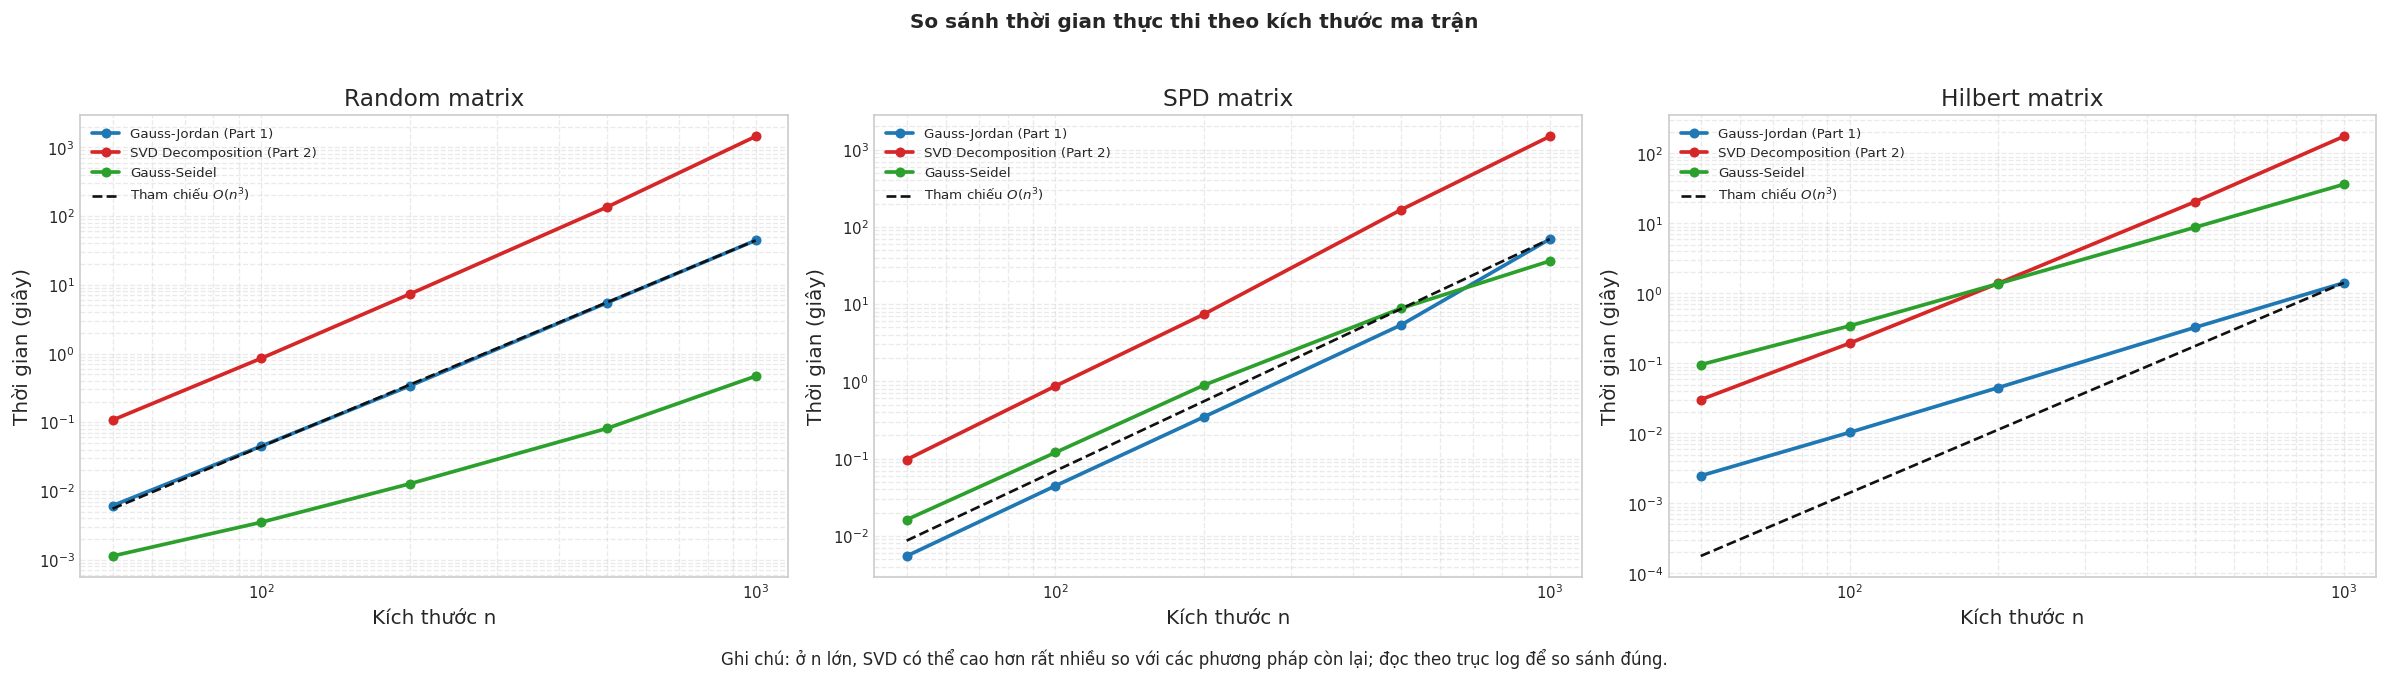

In [13]:
def plot_time_loglog(dataframe: pd.DataFrame) -> None:
    """Vẽ thời gian chạy trung bình theo n trên thang log-log cho từng loại ma trận."""

    # Chia bố cục thành 3 ô, mỗi ô tương ứng với một loại ma trận
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharex=True)
    fig.suptitle("So sánh thời gian thực thi theo kích thước ma trận", fontweight="bold", y=0.98)

    for ax, matrix_type in zip(axes, MATRIX_ORDER):
        subset = dataframe[dataframe["matrix_type"] == matrix_type].copy()

        # Vẽ từng phương pháp trên cùng một trục để so sánh trực tiếp
        for method in METHOD_ORDER:
            method_data = subset[subset["method"] == method].sort_values("n")
            if method_data.empty:
                continue

            ax.loglog(
                method_data["n"],
                method_data["avg_time_sec"],
                marker="o",
                linewidth=2.2,
                markersize=5,
                color=METHOD_COLORS[method],
                label=method,
            )

        # Thêm đường tham chiếu O(n^3) để đối chiếu với lý thuyết
        reference_source = subset[subset["method"] == "Gauss-Jordan (Part 1)"].sort_values("n")
        if not reference_source.empty:
            anchor_n = reference_source["n"].iloc[-1]
            anchor_time = reference_source["avg_time_sec"].iloc[-1]
            scale_c = anchor_time / (anchor_n ** 3)
            reference_n = reference_source["n"].to_numpy()
            reference_time = scale_c * (reference_n ** 3)
            ax.loglog(
                reference_n,
                reference_time,
                linestyle="--",
                color="#111111",
                linewidth=1.6,
                label=r"Tham chiếu $O(n^3)$",
            )

        ax.set_title(MATRIX_LABELS[matrix_type])
        ax.set_xlabel("Kích thước n")
        ax.set_ylabel("Thời gian (giây)")
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.tick_params(axis="both", which="major", labelsize=9)
        ax.legend(fontsize=8, frameon=False, loc="best")

    fig.text(
        0.5,
        -0.01,
        "Ghi chú: ở n lớn, SVD có thể cao hơn rất nhiều so với các phương pháp còn lại; đọc theo trục log để so sánh đúng.",
        ha="center",
        fontsize=10,
    )
    fig.tight_layout(rect=(0, 0.02, 1, 0.95))
    plt.show()


print("### Biểu đồ thời gian chạy")
plot_time_loglog(success_df)


### Biểu đồ sai số tương đối


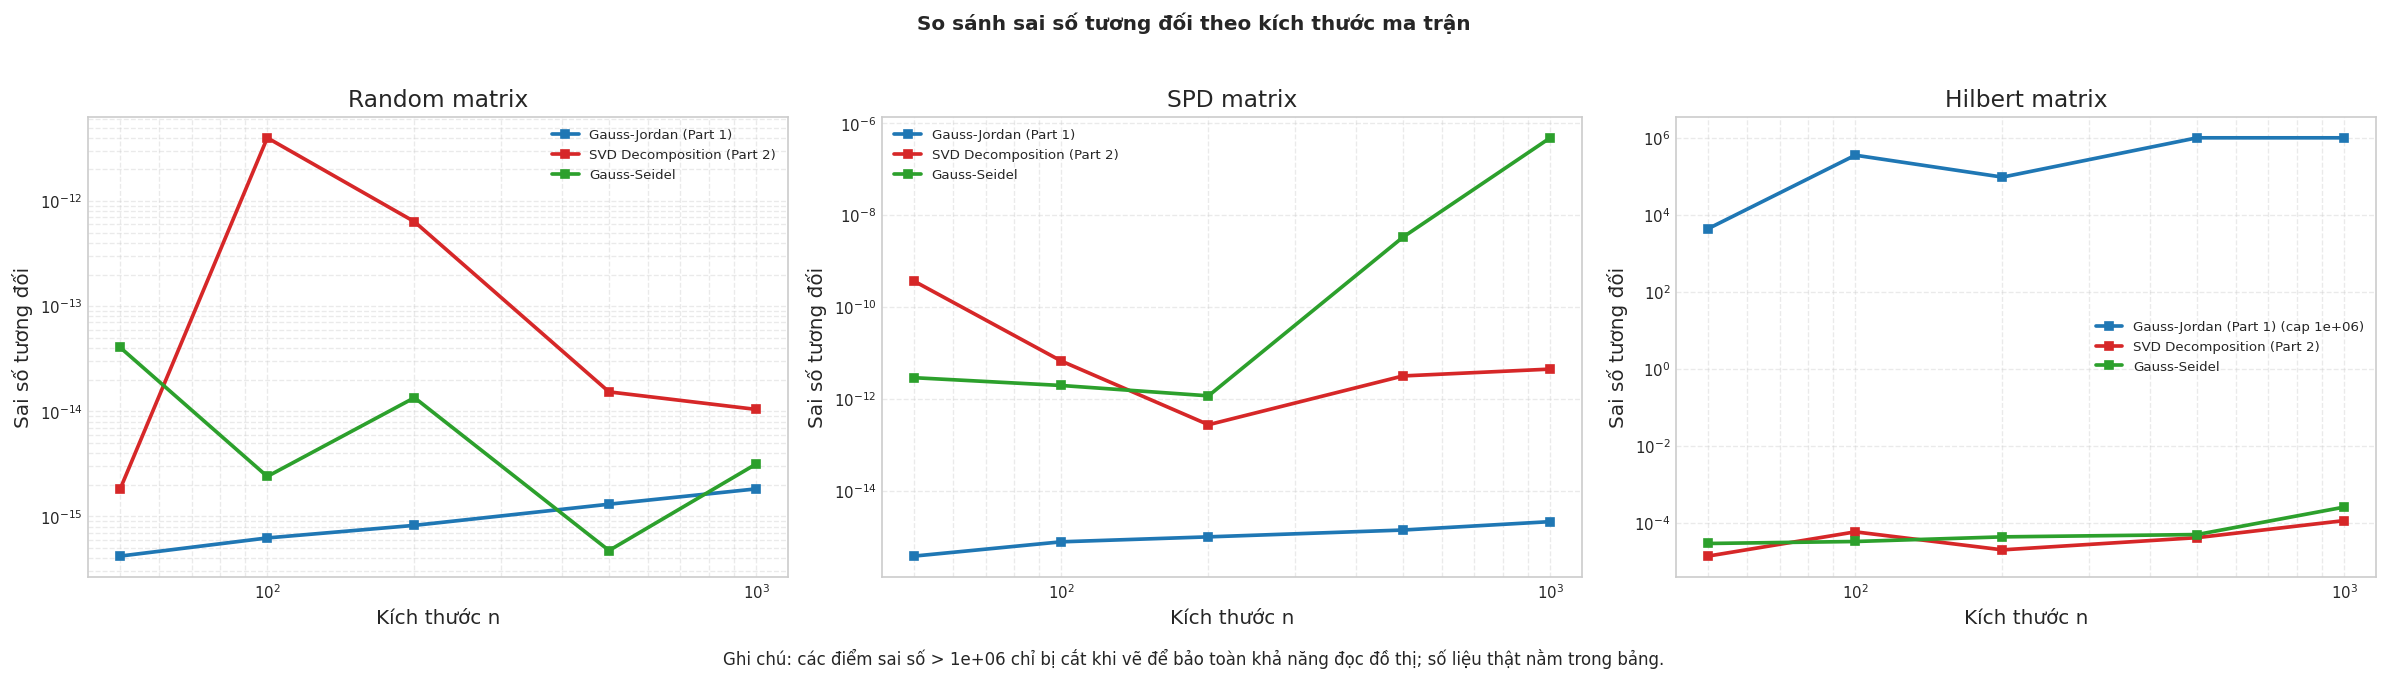

In [14]:
def plot_error_loglog(dataframe: pd.DataFrame, cap_value: float = ERROR_PLOT_CAP) -> None:
    """Vẽ sai số tương đối theo n trên thang log-log cho từng loại ma trận.

    Với outlier quá lớn (đặc biệt Hilbert + Gauss-Jordan), chỉ cắt ngưỡng khi vẽ
    để giữ biểu đồ dễ đọc. Bảng số liệu vẫn hiển thị giá trị thật.
    """

    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharex=True, sharey=False)
    fig.suptitle("So sánh sai số tương đối theo kích thước ma trận", fontweight="bold", y=0.98)

    for ax, matrix_type in zip(axes, MATRIX_ORDER):
        subset = dataframe[dataframe["matrix_type"] == matrix_type].copy()

        for method in METHOD_ORDER:
            method_data = subset[subset["method"] == method].sort_values("n").copy()
            if method_data.empty:
                continue

            # Chỉ cắt ngưỡng cho phần hiển thị đồ thị để tránh mất khả năng đọc.
            y_plot = method_data["avg_relative_error"].clip(upper=cap_value)
            clipped_count = int((method_data["avg_relative_error"] > cap_value).sum())
            label = method if clipped_count == 0 else f"{method} (cap {cap_value:.0e})"

            ax.loglog(
                method_data["n"],
                y_plot,
                marker="s",
                linewidth=2.2,
                markersize=5,
                color=METHOD_COLORS[method],
                label=label,
            )

        ax.set_title(MATRIX_LABELS[matrix_type])
        ax.set_xlabel("Kích thước n")
        ax.set_ylabel("Sai số tương đối")
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.tick_params(axis="both", which="major", labelsize=9)
        ax.legend(fontsize=8, frameon=False, loc="best")

    fig.text(
        0.5,
        -0.01,
        f"Ghi chú: các điểm sai số > {cap_value:.0e} chỉ bị cắt khi vẽ để bảo toàn khả năng đọc đồ thị; số liệu thật nằm trong bảng.",
        ha="center",
        fontsize=10,
    )
    fig.tight_layout(rect=(0, 0.02, 1, 0.95))
    plt.show()


print("### Biểu đồ sai số tương đối")
plot_error_loglog(success_df)


### So sánh trực tiếp tại n = 1000


#### Bảng thời gian chạy (giây)

,Random matrix,SPD matrix,Hilbert matrix
Phương pháp,,,
Gauss-Jordan (Part 1),44.2364,69.3527,1.4179
SVD Decomposition (Part 2),1441.2578,1482.2361,175.5360
Gauss-Seidel,0.4684,36.0938,36.2495


#### Bảng sai số tương đối (giá trị thật, không cắt ngưỡng)

,Random matrix,SPD matrix,Hilbert matrix
Phương pháp,,,
Gauss-Jordan (Part 1),1.83e-15,2.11e-15,5.93e+09
SVD Decomposition (Part 2),1.04e-14,4.44e-12,1.16e-04
Gauss-Seidel,3.16e-15,4.84e-07,2.60e-04


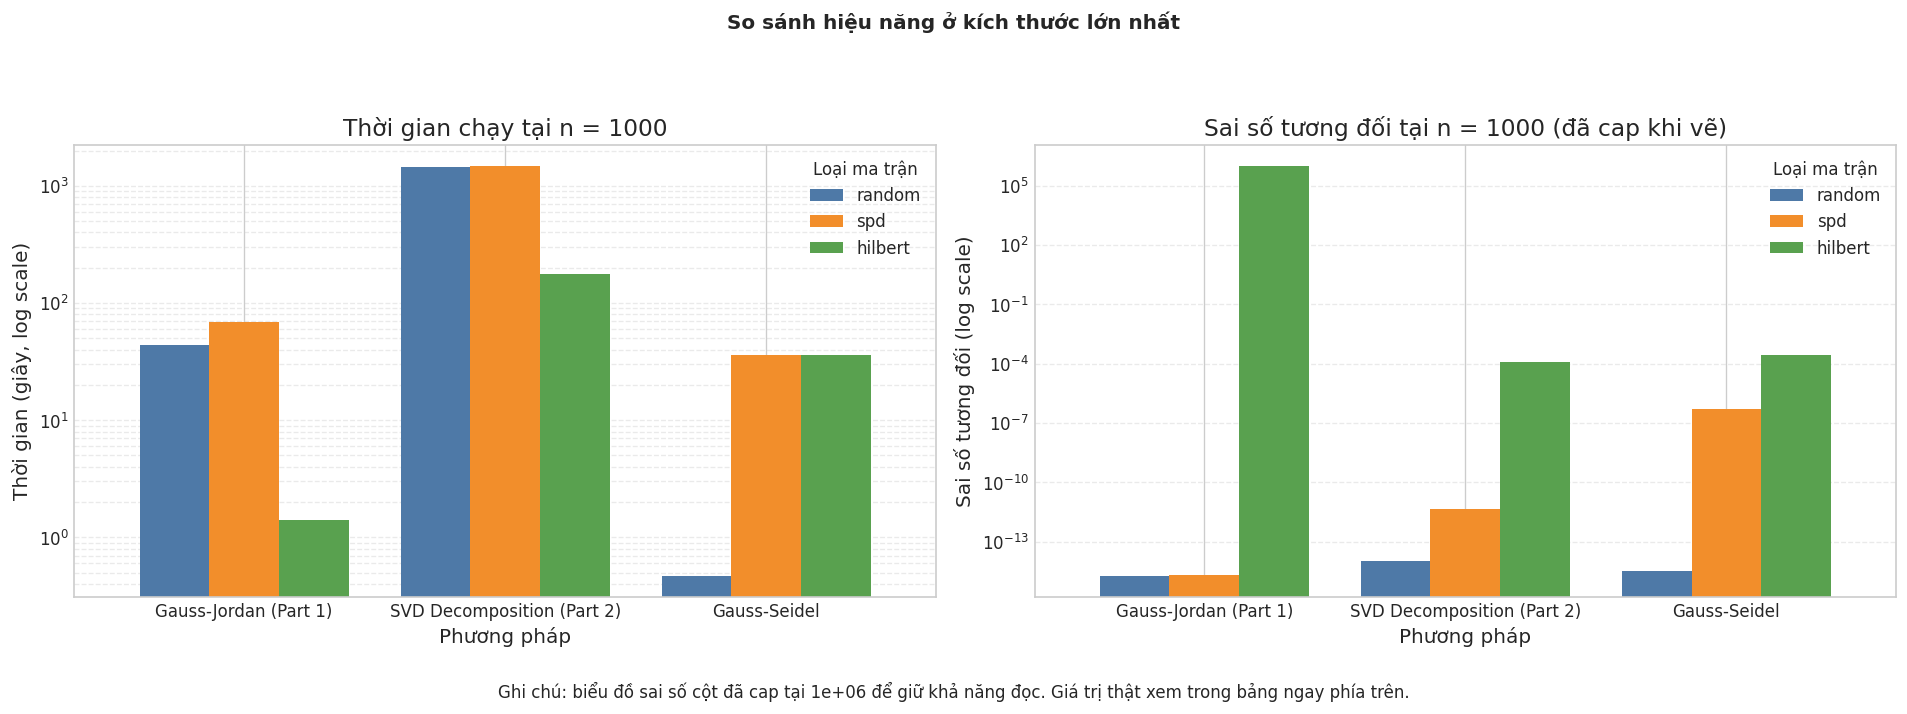

In [15]:
# Lấy kích thước lớn nhất đã benchmark để so sánh trực tiếp giữa các phương pháp
comparison_n = int(df["n"].max())
comparison_df = success_df[success_df["n"] == comparison_n].copy()

# Chuyển dữ liệu sang dạng bảng chéo: hàng là phương pháp, cột là loại ma trận
comparison_time = (
    comparison_df.pivot(index="method", columns="matrix_type", values="avg_time_sec")
    .reindex(METHOD_ORDER)
    .reindex(columns=MATRIX_ORDER)
)
comparison_error = (
    comparison_df.pivot(index="method", columns="matrix_type", values="avg_relative_error")
    .reindex(METHOD_ORDER)
    .reindex(columns=MATRIX_ORDER)
)

# Định dạng bảng để trình bày trong notebook và báo cáo
comparison_time_display = comparison_time.apply(lambda col: col.map(format_seconds))
comparison_error_display = comparison_error.apply(lambda col: col.map(format_scientific))
comparison_time_display.columns = [MATRIX_LABELS[col] for col in comparison_time_display.columns]
comparison_error_display.columns = [MATRIX_LABELS[col] for col in comparison_error_display.columns]
comparison_time_display.index.name = "Phương pháp"
comparison_error_display.index.name = "Phương pháp"

print(f"### So sánh trực tiếp tại n = {comparison_n}")
display(Markdown("#### Bảng thời gian chạy (giây)"))
display(comparison_time_display)
display(Markdown("#### Bảng sai số tương đối (giá trị thật, không cắt ngưỡng)"))
display(comparison_error_display)

# Vẽ hai biểu đồ cột trên thang log để thấy rõ chênh lệch giữa các phương pháp
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
comparison_time.plot(
    kind="bar",
    ax=axes[0],
    color=["#4e79a7", "#f28e2b", "#59a14f"],
    width=0.8,
)
axes[0].set_yscale("log")
axes[0].set_title(f"Thời gian chạy tại n = {comparison_n}")
axes[0].set_xlabel("Phương pháp")
axes[0].set_ylabel("Thời gian (giây, log scale)")
axes[0].grid(True, axis="y", which="both", linestyle="--", alpha=0.4)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Loại ma trận", frameon=False)

# Với biểu đồ sai số cột, cắt ngưỡng hiển thị để tránh outlier làm bẹp các cột còn lại.
comparison_error_plot = comparison_error.clip(upper=ERROR_PLOT_CAP)
comparison_error_plot.plot(
    kind="bar",
    ax=axes[1],
    color=["#4e79a7", "#f28e2b", "#59a14f"],
    width=0.8,
)
axes[1].set_yscale("log")
axes[1].set_title(f"Sai số tương đối tại n = {comparison_n} (đã cap khi vẽ)")
axes[1].set_xlabel("Phương pháp")
axes[1].set_ylabel("Sai số tương đối (log scale)")
axes[1].grid(True, axis="y", which="both", linestyle="--", alpha=0.4)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Loại ma trận", frameon=False)

fig.suptitle("So sánh hiệu năng ở kích thước lớn nhất", fontweight="bold", y=1.02)
fig.text(
    0.5,
    -0.02,
    f"Ghi chú: biểu đồ sai số cột đã cap tại {ERROR_PLOT_CAP:.0e} để giữ khả năng đọc. Giá trị thật xem trong bảng ngay phía trên.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()


## 3.2 Nhận Xét và Kết Luận

Các nhận xét dưới đây được rút ra trực tiếp từ bảng số liệu và các biểu đồ benchmark ở phía trên (bộ dữ liệu mới).

**1. Về thời gian thực thi**
- Với ma trận **random**, **Gauss-Seidel** là nhanh nhất ở toàn bộ kích thước đã đo. Tại $n = 1000$, thời gian trung bình của Gauss-Seidel là **0.468 s**, nhanh hơn rất nhiều so với Gauss-Jordan (**44.236 s**) và SVD (**1441.258 s**).
- Với ma trận **SPD**, ở $n = 1000$ phương pháp nhanh nhất theo thời gian là **Gauss-Seidel** (**36.094 s**), tiếp theo là Gauss-Jordan (**69.353 s**), còn SVD chậm nhất (**1482.236 s**).
- Với ma trận **Hilbert**, thứ hạng thời gian đảo chiều: **Gauss-Jordan** nhanh nhất (**1.418 s**) nhưng độ chính xác kém; Gauss-Seidel (**36.250 s**) và SVD (**175.536 s**) chậm hơn.
- Trên đồ thị log-log, các phương pháp trực tiếp vẫn thể hiện xu hướng tăng nhanh theo kích thước, gần với dạng tăng bậc cao.

**2. Về sai số và độ ổn định số**
- Trên ma trận **random**, cả ba phương pháp đều cho sai số rất nhỏ (cỡ $10^{-15}$ đến $10^{-14}$), cho thấy bài toán ổn định và lời giải đáng tin cậy.
- Trên ma trận **SPD**, Gauss-Jordan vẫn giữ sai số nhỏ (cỡ $10^{-15}$), SVD ở mức $10^{-10}$ đến $10^{-12}$, còn Gauss-Seidel bắt đầu thoái hóa ở kích thước lớn (ví dụ $4.84 \times 10^{-7}$ tại $n=1000$).
- Trên ma trận **Hilbert**, sai số của Gauss-Jordan tăng rất mạnh, tại $n=1000$ lên tới khoảng **$5.93 × 10^9$**. Còn **SVD** ổn định hơn rõ rệt so với hai phương pháp còn lại (khoảng $10^{-5}$ đến $10^{-4}$), trong khi Gauss-Seidel không hội tụ hoàn toàn và dừng ở ngưỡng lặp tối đa.

**3. Kết luận chung**
- Không có một phương pháp tối ưu cho mọi loại ma trận: cần cân bằng giữa **tốc độ** và **độ ổn định số**.
- Nếu ưu tiên tốc độ trên bài toán có cấu trúc thuận lợi (đặc biệt random), **Gauss-Seidel** cho hiệu năng rất tốt.
- Nếu dữ liệu có nguy cơ kém điều kiện (như Hilbert), **SVD** là lựa chọn an toàn hơn về sai số, dù chi phí thời gian cao.
- **Gauss-Jordan** có thể nhanh ở một số trường hợp nhưng dễ mất ổn định số trên bài toán kém điều kiện, nên cần thận trọng khi diễn giải kết quả.
